<a href="https://colab.research.google.com/github/triksoft/Machine_Learning/blob/main/ML_Lab6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Trial


In [ ]:
# ============================================================
# LAB 06
# Performance Comparison of K-NN Implementations
#
# Versions compared:
# 1. Student-written KNN
# 2. Scikit-Learn KNN
# 3. GenAI-developed KNN
# ============================================================

import os
import zipfile
import time
import unittest

import numpy as np
import pandas as pd
import mne

from scipy.signal import welch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [ ]:
# ============================================================
# DATASET HANDLING
#
# GenAI tool used: ChatGPT
# Purpose: Code generation and modular restructuring.
# ============================================================


def extract_zip_file(zip_path, output_directory):
    """
    Extract every file contained in the supplied ZIP archive.

    The output directory is created automatically if required.
    """

    os.makedirs(
        output_directory,
        exist_ok=True
    )

    with zipfile.ZipFile(zip_path, "r") as archive:
        archive.extractall(output_directory)

    return output_directory


def get_edf_files(directory):
    """
    Search recursively for all EDF files.
    """

    edf_files = []

    for root, _, files in os.walk(directory):

        for filename in files:

            if filename.lower().endswith(".edf"):

                full_path = os.path.join(
                    root,
                    filename
                )

                edf_files.append(full_path)

    return sorted(edf_files)


def get_class_label(file_path):
    """
    Assign the class according to the EDF filename.

    h01, h02, ... -> Healthy
    s01, s02, ... -> Schizophrenia
    """

    filename = os.path.basename(
        file_path
    ).lower()

    if filename.startswith("h"):
        return "Healthy"

    if filename.startswith("s"):
        return "Schizophrenia"

    return None


def extract_features_from_edf(file_path):
    """
    Extract EEG frequency-band power features.

    Five bands are used:
    Delta, Theta, Alpha, Beta and Gamma.

    The five features are calculated for every EEG channel.
    """

    raw = mne.io.read_raw_edf(
        file_path,
        preload=True,
        verbose=False
    )

    # Keep EEG channels only
    raw.pick("eeg")

    eeg_data = raw.get_data()

    sampling_frequency = raw.info["sfreq"]

    frequency_bands = {
        "delta": (0.5, 4),
        "theta": (4, 8),
        "alpha": (8, 13),
        "beta": (13, 30),
        "gamma": (30, 45)
    }

    features = []

    for channel in eeg_data:

        # Remove channel DC component
        channel = channel - np.mean(channel)

        frequencies, power_spectrum = welch(
            channel,
            fs=sampling_frequency,
            nperseg=min(
                1024,
                len(channel)
            )
        )

        for lower, upper in frequency_bands.values():

            selected = (
                (frequencies >= lower) &
                (frequencies <= upper)
            )

            band_power = np.trapezoid(
                power_spectrum[selected],
                frequencies[selected]
            )

            features.append(
                band_power
            )

    return np.asarray(features)


def create_dataset(edf_files):
    """
    Convert all valid EDF recordings into X and y.
    """

    feature_matrix = []
    labels = []

    for file_path in edf_files:

        label = get_class_label(
            file_path
        )

        if label is None:
            continue

        try:

            feature_vector = extract_features_from_edf(
                file_path
            )

            feature_matrix.append(
                feature_vector
            )

            labels.append(label)

        except Exception as error:

            print(
                "Error processing",
                os.path.basename(file_path),
                ":",
                error
            )

    return (
        np.asarray(feature_matrix),
        np.asarray(labels)
    )

In [ ]:
# ============================================================
# LOAD COMPLETE PROJECT DATASET
# ============================================================

ZIP_PATH = "/content/dataverse_files.zip"

# This directory is created automatically.
EXTRACTION_DIRECTORY = "/content/eeg_data"

extract_zip_file(
    ZIP_PATH,
    EXTRACTION_DIRECTORY
)

edf_files = get_edf_files(
    EXTRACTION_DIRECTORY
)

X, y = create_dataset(
    edf_files
)

print("==============================================")
print("DATASET INFORMATION")
print("==============================================")

print(
    "Number of EDF files:",
    len(edf_files)
)

print(
    "Number of samples:",
    X.shape[0]
)

print(
    "Number of features:",
    X.shape[1]
)

print(
    "Feature matrix shape:",
    X.shape
)

print(
    "Label vector shape:",
    y.shape
)

print("\nClass distribution:")
print(
    pd.Series(y).value_counts()
)

DATASET INFORMATION
Number of EDF files: 28
Number of samples: 28
Number of features: 95
Feature matrix shape: (28, 95)
Label vector shape: (28,)

Class distribution:
Healthy          14
Schizophrenia    14
Name: count, dtype: int64


In [ ]:
# ============================================================
# A1(a) — ENCODING
#
# GenAI tool used: ChatGPT
# ============================================================

def encode_target(labels):
    """
    Convert categorical class labels into integer values.
    """

    label_encoder = LabelEncoder()

    encoded_labels = label_encoder.fit_transform(
        labels
    )

    return (
        encoded_labels,
        label_encoder
    )


y_encoded, label_encoder = encode_target(
    y
)

print("==============================================")
print("ENCODING")
print("==============================================")

for index, class_name in enumerate(
    label_encoder.classes_
):

    print(
        class_name,
        "->",
        index
    )

print("\nEncoded target:")
print(y_encoded)

ENCODING
Healthy -> 0
Schizophrenia -> 1

Encoded target:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [ ]:
# ============================================================
# A1(b) — TRAIN / TEST SPLIT
# ============================================================

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

print("==============================================")
print("TRAIN / TEST SPLIT")
print("==============================================")

print(
    "Training data:",
    X_train_raw.shape
)

print(
    "Testing data :",
    X_test_raw.shape
)

print("\nTraining class distribution:")
print(
    pd.Series(y_train).value_counts()
)

print("\nTesting class distribution:")
print(
    pd.Series(y_test).value_counts()
)

TRAIN / TEST SPLIT
Training data: (19, 95)
Testing data : (9, 95)

Training class distribution:
1    10
0     9
Name: count, dtype: int64

Testing class distribution:
0    5
1    4
Name: count, dtype: int64


In [ ]:
# ============================================================
# A1(c) — DATA IMPUTATION AND STANDARDIZATION
#
# GenAI tool used: ChatGPT
#
# Important:
# The preprocessing parameters are learned only from the
# training data to avoid test-data leakage.
# ============================================================

def preprocess_features(training_data, testing_data):
    """
    Impute missing values using the median and standardize
    the resulting feature values.

    Both transformations are fitted using training data only.
    """

    imputer = SimpleImputer(
        strategy="median"
    )

    training_imputed = imputer.fit_transform(
        training_data
    )

    testing_imputed = imputer.transform(
        testing_data
    )

    scaler = StandardScaler()

    training_scaled = scaler.fit_transform(
        training_imputed
    )

    testing_scaled = scaler.transform(
        testing_imputed
    )

    return (
        training_scaled,
        testing_scaled,
        imputer,
        scaler
    )


X_train, X_test, imputer, scaler = preprocess_features(
    X_train_raw,
    X_test_raw
)

print("==============================================")
print("PREPROCESSING")
print("==============================================")

print(
    "Training shape:",
    X_train.shape
)

print(
    "Testing shape:",
    X_test.shape
)

print(
    "Training missing values:",
    np.isnan(X_train).sum()
)

print(
    "Testing missing values:",
    np.isnan(X_test).sum()
)

PREPROCESSING
Training shape: (19, 95)
Testing shape: (9, 95)
Training missing values: 0
Testing missing values: 0


In [ ]:
# ============================================================
# A1(d) — DISTANCE CALCULATION
#
# GenAI tool used: ChatGPT
# ============================================================


def euclidean_distance(x1, x2):
    """Return Euclidean distance between two vectors."""

    difference = x1 - x2

    return np.linalg.norm(
        difference
    )


def manhattan_distance(x1, x2):
    """Return Manhattan distance between two vectors."""

    return np.sum(
        np.abs(x1 - x2)
    )


def calculate_metric(x1, x2, metric):
    """
    Select the requested distance metric.
    """

    if metric == "euclidean":

        return euclidean_distance(
            x1,
            x2
        )

    elif metric == "manhattan":

        return manhattan_distance(
            x1,
            x2
        )

    else:

        raise ValueError(
            "Unsupported distance metric"
        )

In [ ]:
# ============================================================
# A1(e) — QUICK SORT
#
# GenAI tool used: ChatGPT
# ============================================================


def quick_sort(items):
    """
    Sort (distance, label) pairs using Quick Sort.
    """

    if len(items) <= 1:
        return items.copy()

    pivot = items[
        len(items) // 2
    ][0]

    lower = [
        item
        for item in items
        if item[0] < pivot
    ]

    equal = [
        item
        for item in items
        if item[0] == pivot
    ]

    higher = [
        item
        for item in items
        if item[0] > pivot
    ]

    return (
        quick_sort(lower)
        + equal
        + quick_sort(higher)
    )

In [ ]:
# ============================================================
# A1(e) — MERGE SORT
#
# GenAI tool used: ChatGPT
# ============================================================


def merge_sort(items):
    """
    Sort (distance, label) pairs using Merge Sort.
    """

    if len(items) <= 1:
        return items.copy()

    midpoint = len(items) // 2

    left_half = merge_sort(
        items[:midpoint]
    )

    right_half = merge_sort(
        items[midpoint:]
    )

    merged = []

    left_index = 0
    right_index = 0

    while (
        left_index < len(left_half)
        and right_index < len(right_half)
    ):

        if (
            left_half[left_index][0]
            <=
            right_half[right_index][0]
        ):

            merged.append(
                left_half[left_index]
            )

            left_index += 1

        else:

            merged.append(
                right_half[right_index]
            )

            right_index += 1

    merged.extend(
        left_half[left_index:]
    )

    merged.extend(
        right_half[right_index:]
    )

    return merged

In [ ]:
# ============================================================
# A1(e) — HEAP SORT
#
# GenAI tool used: ChatGPT
# ============================================================


def heap_sort(items):
    """
    Sort (distance, label) pairs using Heap Sort.
    """

    values = items.copy()

    def heapify(size, root):

        largest = root

        left = (
            2 * root + 1
        )

        right = (
            2 * root + 2
        )

        if (
            left < size
            and values[left][0]
            > values[largest][0]
        ):

            largest = left

        if (
            right < size
            and values[right][0]
            > values[largest][0]
        ):

            largest = right

        if largest != root:

            values[root], values[largest] = (
                values[largest],
                values[root]
            )

            heapify(
                size,
                largest
            )

    size = len(values)

    for index in range(
        size // 2 - 1,
        -1,
        -1
    ):

        heapify(
            size,
            index
        )

    for index in range(
        size - 1,
        0,
        -1
    ):

        values[0], values[index] = (
            values[index],
            values[0]
        )

        heapify(
            index,
            0
        )

    return values

In [ ]:
# ============================================================
# A1(e) — SORTING CONFIGURATION
#
# GenAI tool used: ChatGPT
# ============================================================


def sort_neighbors(distance_pairs, method):
    """
    Select the sorting algorithm using a configuration value.
    """

    if method == "quick":

        return quick_sort(
            distance_pairs
        )

    if method == "merge":

        return merge_sort(
            distance_pairs
        )

    if method == "heap":

        return heap_sort(
            distance_pairs
        )

    raise ValueError(
        "Sorting method must be quick, merge or heap"
    )

In [ ]:
# ============================================================
# A1(f) — CLASS ASSIGNMENT
#
# GenAI tool used: ChatGPT
# ============================================================


def determine_class(neighbors, weighted=False):
    """
    Determine the class of a test sample.

    Unweighted KNN:
        Each neighbor contributes one vote.

    Weighted KNN:
        Closer neighbors contribute more.

    Tie breaking:
        The class with the smaller total neighbor distance
        is selected.
    """

    votes = {}

    total_distances = {}

    for distance, label in neighbors:

        if label not in votes:

            votes[label] = 0.0
            total_distances[label] = 0.0

        if weighted:

            vote = 1.0 / (
                distance + 1e-12
            )

        else:

            vote = 1.0

        votes[label] += vote

        total_distances[label] += distance

    highest_vote = max(
        votes.values()
    )

    tied_classes = [
        label
        for label, value in votes.items()
        if np.isclose(
            value,
            highest_vote
        )
    ]

    if len(tied_classes) == 1:

        return tied_classes[0]

    # Tie-breaking rule
    return min(
        tied_classes,
        key=lambda label: (
            total_distances[label],
            label
        )
    )

In [ ]:
# ============================================================
# A1 — GENAI-DEVELOPED KNN
#
# GenAI tool used: ChatGPT
#
# This implementation is intentionally structured differently
# from the KNN class used in Lab 5.
# ============================================================


class GenAIKNN:

    def __init__(
        self,
        k=3,
        metric="euclidean",
        sorting_method="merge",
        weighted=False
    ):

        self.k = k
        self.metric = metric
        self.sorting_method = sorting_method
        self.weighted = weighted

        self.X_train = None
        self.y_train = None


    def fit(self, X, y):
        """
        Store training observations.
        """

        if self.k <= 0:

            raise ValueError(
                "k must be greater than zero"
            )

        if self.k > len(X):

            raise ValueError(
                "k cannot exceed training-set size"
            )

        self.X_train = np.asarray(X)
        self.y_train = np.asarray(y)

        return self


    def find_neighbors(self, sample):
        """
        Calculate distances between the test sample and
        every training sample.
        """

        distance_pairs = []

        for row, label in zip(
            self.X_train,
            self.y_train
        ):

            distance = calculate_metric(
                sample,
                row,
                self.metric
            )

            distance_pairs.append(
                (distance, label)
            )

        ordered_pairs = sort_neighbors(
            distance_pairs,
            self.sorting_method
        )

        return ordered_pairs[
            :self.k
        ]


    def predict_one(self, sample):
        """
        Predict the class of a single sample.
        """

        nearest = self.find_neighbors(
            sample
        )

        return determine_class(
            nearest,
            self.weighted
        )


    def predict(self, X):
        """
        Predict classes for multiple samples.
        """

        predictions = []

        for sample in X:

            predictions.append(
                self.predict_one(sample)
            )

        return np.asarray(
            predictions
        )


    def score(self, X, y):
        """
        Calculate classification accuracy.
        """

        predictions = self.predict(X)

        return accuracy_score(
            y,
            predictions
        )

In [ ]:
# ============================================================
# A1 — BASIC GENAI KNN EXPERIMENT
# ============================================================

genai_model = GenAIKNN(
    k=3,
    metric="euclidean",
    sorting_method="merge",
    weighted=False
)

genai_model.fit(
    X_train,
    y_train
)

predicted = genai_model.predict(
    X_test
)

accuracy = genai_model.score(
    X_test,
    y_test
)

print("==============================================")
print("GENAI KNN")
print("==============================================")

print("Actual labels:")
print(y_test)

print("\nPredicted labels:")
print(predicted)

print(
    "\nAccuracy:",
    accuracy
)

print(
    "Accuracy (%):",
    accuracy * 100
)

GENAI KNN
Actual labels:
[0 0 1 1 0 0 0 1 1]

Predicted labels:
[0 0 0 1 0 0 0 0 1]

Accuracy: 0.7777777777777778
Accuracy (%): 77.77777777777779


In [ ]:
# ============================================================
# A2 — WEIGHTED KNN
#
# GenAI tool used: ChatGPT
# ============================================================


weighted_model = GenAIKNN(
    k=3,
    metric="euclidean",
    sorting_method="merge",
    weighted=True
)

weighted_model.fit(
    X_train,
    y_train
)

weighted_predictions = weighted_model.predict(
    X_test
)

weighted_accuracy = weighted_model.score(
    X_test,
    y_test
)

print("==============================================")
print("WEIGHTED KNN")
print("==============================================")

print("Actual labels:")
print(y_test)

print("\nWeighted KNN predictions:")
print(weighted_predictions)

print(
    "\nWeighted KNN accuracy:",
    weighted_accuracy
)

print(
    "Accuracy (%):",
    weighted_accuracy * 100
)

WEIGHTED KNN
Actual labels:
[0 0 1 1 0 0 0 1 1]

Weighted KNN predictions:
[0 0 0 1 0 0 0 0 1]

Weighted KNN accuracy: 0.7777777777777778
Accuracy (%): 77.77777777777779


In [ ]:
# ============================================================
# A2 — UNIT TEST CASES
#
# GenAI tool used: ChatGPT
# ============================================================


class TestKNN(unittest.TestCase):


    def test_euclidean_distance(self):

        point_a = np.array(
            [0, 0]
        )

        point_b = np.array(
            [3, 4]
        )

        result = euclidean_distance(
            point_a,
            point_b
        )

        self.assertAlmostEqual(
            result,
            5.0
        )


    def test_manhattan_distance(self):

        point_a = np.array(
            [1, 2, 3]
        )

        point_b = np.array(
            [4, 6, 8]
        )

        result = manhattan_distance(
            point_a,
            point_b
        )

        self.assertEqual(
            result,
            12
        )


    def test_quick_sort(self):

        values = [
            (4.0, 0),
            (1.0, 1),
            (3.0, 0),
            (2.0, 1)
        ]

        result = quick_sort(
            values
        )

        distances = [
            item[0]
            for item in result
        ]

        self.assertEqual(
            distances,
            [1.0, 2.0, 3.0, 4.0]
        )


    def test_merge_sort(self):

        values = [
            (8.0, 0),
            (3.0, 1),
            (6.0, 0),
            (2.0, 1)
        ]

        result = merge_sort(
            values
        )

        distances = [
            item[0]
            for item in result
        ]

        self.assertEqual(
            distances,
            [2.0, 3.0, 6.0, 8.0]
        )


    def test_heap_sort(self):

        values = [
            (7.0, 0),
            (1.0, 1),
            (5.0, 0),
            (3.0, 1)
        ]

        result = heap_sort(
            values
        )

        distances = [
            item[0]
            for item in result
        ]

        self.assertEqual(
            distances,
            [1.0, 3.0, 5.0, 7.0]
        )


    def test_majority_voting(self):

        neighbors = [
            (1.0, 0),
            (2.0, 0),
            (3.0, 1)
        ]

        result = determine_class(
            neighbors,
            weighted=False
        )

        self.assertEqual(
            result,
            0
        )


    def test_weighted_voting(self):

        neighbors = [
            (1.0, 1),
            (2.0, 0),
            (5.0, 0)
        ]

        result = determine_class(
            neighbors,
            weighted=True
        )

        self.assertEqual(
            result,
            1
        )


    def test_fit(self):

        model = GenAIKNN(
            k=3
        )

        model.fit(
            X_train,
            y_train
        )

        self.assertEqual(
            model.X_train.shape,
            X_train.shape
        )


    def test_predict(self):

        model = GenAIKNN(
            k=3
        )

        model.fit(
            X_train,
            y_train
        )

        predictions = model.predict(
            X_test
        )

        self.assertEqual(
            len(predictions),
            len(X_test)
        )


    def test_score(self):

        model = GenAIKNN(
            k=3
        )

        model.fit(
            X_train,
            y_train
        )

        result = model.score(
            X_test,
            y_test
        )

        self.assertGreaterEqual(
            result,
            0.0
        )

        self.assertLessEqual(
            result,
            1.0
        )


# Run all tests

test_suite = unittest.defaultTestLoader.loadTestsFromTestCase(
    TestKNN
)

test_runner = unittest.TextTestRunner(
    verbosity=2
)

test_result = test_runner.run(
    test_suite
)

test_euclidean_distance (__main__.TestKNN.test_euclidean_distance) ... ok
test_fit (__main__.TestKNN.test_fit) ... ok
test_heap_sort (__main__.TestKNN.test_heap_sort) ... ok
test_majority_voting (__main__.TestKNN.test_majority_voting) ... ok
test_manhattan_distance (__main__.TestKNN.test_manhattan_distance) ... ok
test_merge_sort (__main__.TestKNN.test_merge_sort) ... ok
test_predict (__main__.TestKNN.test_predict) ... ok
test_quick_sort (__main__.TestKNN.test_quick_sort) ... ok
test_score (__main__.TestKNN.test_score) ... ok
test_weighted_voting (__main__.TestKNN.test_weighted_voting) ... ok

----------------------------------------------------------------------
Ran 10 tests in 0.018s

OK


In [ ]:
# ============================================================
# A3 — VERSION 1
# STUDENT-WRITTEN KNN
#
# This represents the manually implemented KNN version.
# It is kept independent from the GenAIKNN class.
# ============================================================


class StudentKNN:

    def __init__(self, k=3):

        self.k = k
        self.features = None
        self.labels = None


    def fit(self, X, y):

        self.features = np.asarray(X)
        self.labels = np.asarray(y)

        return self


    def predict(self, X):

        predictions = []

        for test_sample in X:

            distance_list = []

            for index in range(
                len(self.features)
            ):

                difference = (
                    test_sample
                    -
                    self.features[index]
                )

                distance = np.sqrt(
                    np.sum(
                        difference ** 2
                    )
                )

                distance_list.append(
                    (
                        distance,
                        self.labels[index]
                    )
                )

            distance_list.sort(
                key=lambda item: item[0]
            )

            nearest = distance_list[
                :self.k
            ]

            counts = {}

            for _, label in nearest:

                counts[label] = (
                    counts.get(label, 0)
                    + 1
                )

            # Majority vote
            prediction = max(
                counts,
                key=counts.get
            )

            predictions.append(
                prediction
            )

        return np.asarray(
            predictions
        )


    def score(self, X, y):

        predictions = self.predict(
            X
        )

        return np.mean(
            predictions == y
        )

In [ ]:
# ============================================================
# A3 — EVALUATION METRICS
# ============================================================


def calculate_metrics(actual, predicted):

    return {
        "Accuracy": accuracy_score(
            actual,
            predicted
        ),

        "Precision": precision_score(
            actual,
            predicted,
            average="weighted",
            zero_division=0
        ),

        "Recall": recall_score(
            actual,
            predicted,
            average="weighted",
            zero_division=0
        ),

        "F1-Score": f1_score(
            actual,
            predicted,
            average="weighted",
            zero_division=0
        )
    }

In [ ]:
# ============================================================
# A3 — 10-RUN PERFORMANCE MEASUREMENT
#
# The average time includes:
#     fit()
#     predict()
#
# The model is recreated for every run.
# ============================================================


def benchmark_model(
    model_creator,
    X_train,
    y_train,
    X_test,
    y_test
):
    """
    Execute a model 10 times and calculate average metrics
    and average computational time.
    """

    times = []
    results = []

    for run in range(10):

        model = model_creator()

        start_time = time.perf_counter()

        model.fit(
            X_train,
            y_train
        )

        predictions = model.predict(
            X_test
        )

        end_time = time.perf_counter()

        elapsed = (
            end_time
            -
            start_time
        )

        times.append(
            elapsed
        )

        results.append(
            calculate_metrics(
                y_test,
                predictions
            )
        )

    average_metrics = {}

    for metric_name in results[0]:

        average_metrics[metric_name] = np.mean(
            [
                result[metric_name]
                for result in results
            ]
        )

    average_time = np.mean(
        times
    )

    return (
        average_metrics,
        average_time
    )

In [ ]:
# ============================================================
# A3 — STUDENT KNN BENCHMARK
# ============================================================


student_metrics, student_time = benchmark_model(
    lambda: StudentKNN(k=3),
    X_train,
    y_train,
    X_test,
    y_test
)

print("Student KNN")
print(
    student_metrics
)

print(
    "Average time:",
    student_time,
    "seconds"
)

Student KNN
{'Accuracy': np.float64(0.7777777777777778), 'Precision': np.float64(0.8412698412698413), 'Recall': np.float64(0.7777777777777778), 'F1-Score': np.float64(0.7592592592592593)}
Average time: 0.0020475069000895018 seconds


In [ ]:
# ============================================================
# A3 — SCIKIT-LEARN KNN BENCHMARK
# ============================================================


sklearn_metrics, sklearn_time = benchmark_model(
    lambda: KNeighborsClassifier(
        n_neighbors=3,
        metric="euclidean"
    ),
    X_train,
    y_train,
    X_test,
    y_test
)

print("Scikit-Learn KNN")
print(
    sklearn_metrics
)

print(
    "Average time:",
    sklearn_time,
    "seconds"
)

Scikit-Learn KNN
{'Accuracy': np.float64(0.7777777777777778), 'Precision': np.float64(0.8412698412698413), 'Recall': np.float64(0.7777777777777778), 'F1-Score': np.float64(0.7592592592592593)}
Average time: 0.008809235999797238 seconds


In [ ]:
# ============================================================
# A3 — GENAI KNN BENCHMARK
# ============================================================


genai_metrics, genai_time = benchmark_model(
    lambda: GenAIKNN(
        k=3,
        metric="euclidean",
        sorting_method="merge",
        weighted=False
    ),
    X_train,
    y_train,
    X_test,
    y_test
)

print("GenAI KNN")
print(
    genai_metrics
)

print(
    "Average time:",
    genai_time,
    "seconds"
)

GenAI KNN
{'Accuracy': np.float64(0.7777777777777778), 'Precision': np.float64(0.8412698412698413), 'Recall': np.float64(0.7777777777777778), 'F1-Score': np.float64(0.7592592592592593)}
Average time: 0.00261141309983941 seconds


In [ ]:
# ============================================================
# A3 — FINAL PERFORMANCE COMPARISON
# ============================================================


performance_table = pd.DataFrame({

    "Implementation": [
        "Student KNN",
        "Scikit-Learn KNN",
        "GenAI KNN"
    ],

    "Accuracy": [
        student_metrics["Accuracy"],
        sklearn_metrics["Accuracy"],
        genai_metrics["Accuracy"]
    ],

    "Precision": [
        student_metrics["Precision"],
        sklearn_metrics["Precision"],
        genai_metrics["Precision"]
    ],

    "Recall": [
        student_metrics["Recall"],
        sklearn_metrics["Recall"],
        genai_metrics["Recall"]
    ],

    "F1-Score": [
        student_metrics["F1-Score"],
        sklearn_metrics["F1-Score"],
        genai_metrics["F1-Score"]
    ],

    "Average Time (10 Runs)": [
        student_time,
        sklearn_time,
        genai_time
    ]
})


print(
    performance_table.to_string(
        index=False
    )
)

  Implementation  Accuracy  Precision   Recall  F1-Score  Average Time (10 Runs)
     Student KNN  0.777778    0.84127 0.777778  0.759259                0.002048
Scikit-Learn KNN  0.777778    0.84127 0.777778  0.759259                0.008809
       GenAI KNN  0.777778    0.84127 0.777778  0.759259                0.002611


In [ ]:
# ============================================================
# A3 — REPORT TABLE
# ============================================================


report_table = performance_table.copy()

score_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
]

for column in score_columns:

    report_table[column] = (
        report_table[column] * 100
    ).round(2)


report_table[
    "Average Time (10 Runs)"
] = report_table[
    "Average Time (10 Runs)"
].round(6)


print(
    report_table.to_string(
        index=False
    )
)

  Implementation  Accuracy  Precision  Recall  F1-Score  Average Time (10 Runs)
     Student KNN     77.78      84.13   77.78     75.93                0.002048
Scikit-Learn KNN     77.78      84.13   77.78     75.93                0.008809
       GenAI KNN     77.78      84.13   77.78     75.93                0.002611


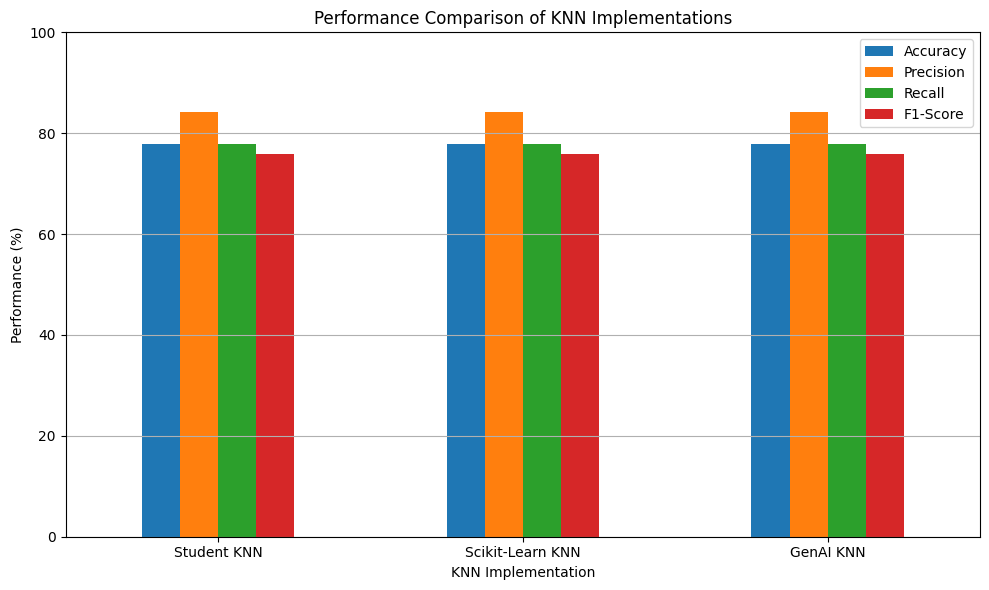

In [ ]:
# ============================================================
# A3 — PERFORMANCE GRAPH
# ============================================================

import matplotlib.pyplot as plt


graph_data = report_table.set_index(
    "Implementation"
)[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ]
]


graph_data.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.xlabel(
    "KNN Implementation"
)

plt.ylabel(
    "Performance (%)"
)

plt.title(
    "Performance Comparison of KNN Implementations"
)

plt.xticks(
    rotation=0
)

plt.ylim(
    0,
    100
)

plt.legend()

plt.grid(
    axis="y"
)

plt.tight_layout()

plt.show()